# 02 - Model Regimes: V1 -> V2 -> V3 Validation

The simulator supports three regimes of increasing physical realism:

| Regime | Skin model | Donor | Clearance |
|--------|-----------|-------|-----------|
| **V1** | Homogeneous $D$ | Infinite dose | None |
| **V2** | 3-layer (SC / VE / dermis) with literature $D$ values | Infinite dose | Optional |
| **V3** | 3-layer + spatial heterogeneity | Finite (time-decaying) dose | Included in final workflow |

This notebook runs one simulation from each regime and compares:
- Concentration fields and diffusivity maps
- Flux curve shapes ($J(t)$)
- Extracted scalars ($P$, $J_{\text{ss}}$, $T_{\text{lag}}$, $J_{\text{peak}}$, $t_{\text{peak}}$, $M_{\text{delivered,24h}}$)

## Regime Design: Same PDE, Different Assumptions

All regimes are based on the same diffusion-reaction equation:

$$
\frac{\partial C}{\partial t} = \nabla \cdot (D\nabla C) - kC
$$

The regimes differ in how $D$, $k$, and donor boundary conditions are specified:

- **V1:** $D$ constant, $k=0$, infinite-dose donor.
  - Think of V1 as the "unit test" physics model: simplest case, easiest to reason about.
- **V2:** layered $D(z)$ (SC/VE/dermis), optional dermal clearance $k(z)$, infinite-dose donor.
  - V2 adds biologically meaningful layer resistance, especially the stratum corneum barrier.
- **V3:** layered $D(z)$ plus spatial heterogeneity $D(z,x)$, dermal clearance $k(z)$, and finite-dose donor decay.
  - V3 adds variability and donor depletion, making outputs closer to realistic topical delivery behaviour.

Finite-dose donor in V3:

$$
C_d(t)=C_0 e^{-\lambda t}
$$

## Literature Basis For Regime Progression

The progression V1 -> V2 -> V3 is motivated by literature-backed modelling priorities:
- Barrier-dominant skin transport and layered interpretation (Prausnitz and Langer, 2008).
- Calibration anchors for permeability and lag time from human-skin lidocaine data (Adamiak-Giera et al., 2023).
- Standard diffusion-model verification framing (Crank, 1975), used in Notebook 03.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import contextlib, io

from skin_diffusion.notebook_helpers import setup_repo_root
from skin_diffusion.config import load_config
from skin_diffusion.run_utils import run_simulation

repo_root = setup_repo_root()

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
})
print('Setup complete OK')


Setup complete OK


## 1 - Run all three regimes

In [ ]:
configs = {
    'V1 - Homogeneous':  'configs/sim/v1_baseline.yaml',
    'V2 - Layered (literature)': 'configs/sim/v2_lidocaine_compare.yaml',
    'V3 - Heterogeneous + clearance': 'configs/sim/v3_layers_literature_clearance.yaml',
}

runs = {}
for label, cfg_path in configs.items():
    print(f'\n{label}')
    cfg = load_config(cfg_path)
    # silence tqdm bars for notebook
    with contextlib.redirect_stderr(io.StringIO()):
        C_snap, t_save, D_field, k_field, patch_mask, diag, met, stab = run_simulation(cfg)
    runs[label] = dict(
        cfg=cfg, C_snap=C_snap, t_save=t_save, D_field=D_field,
        patch_mask=patch_mask, diagnostics=diag, metrics=met, stability=stab,
    )
    print(f'Grid: {C_snap.shape[1]}x{C_snap.shape[2]}, T={cfg.grid.T}s, '
          f'snapshots={C_snap.shape[0]}')
    print(f'P={met.get("P")}, J_ss={met.get("J_ss")}, Tlag={met.get("Tlag")}, '
          f'J_peak={met.get("J_peak")}, t_peak={met.get("t_peak")}, M24={met.get("M_delivered_24h")}')

print('\nAll regimes complete.')



V1 - Homogeneous
Grid: 64x64, T=1.0s, snapshots=4001
P=1.5873015858565487, J_ss=1.5873015858565487, Tlag=0.06612083273635753, J_peak=1.5873015872513596, t_peak=1.0, M24=1.4823478835999022

V2 - Layered (literature)
Grid: 64x64, T=86400.0s, snapshots=1441
P=7.3797672044557e-07, J_ss=7.3797672044557e-07, Tlag=5046.425888242676, J_peak=7.379767205585702e-07, t_peak=86400.0, M24=0.060037043822587996

V3 - Heterogeneous + clearance (final base)
Grid: 64x64, T=86400.0s, snapshots=1441
P=1.0832085529719384e-17, J_ss=1.0832085529719384e-17, Tlag=None, J_peak=3.422542231703819e-10, t_peak=3300.0, M24=2.262932973587581e-06

All regimes complete.


## 2 - Diffusivity fields

- **V1** — Spatially uniform $D$ field (single colour throughout the domain).
- **V2** — Three distinct horizontal layers: thin, low-$D$ stratum corneum at the top; mid-$D$ viable epidermis; higher-$D$ dermis below — matching literature values.
- **V3** — Retains the layered structure but adds visible speckled heterogeneity, representing biological variability in tissue diffusivity.

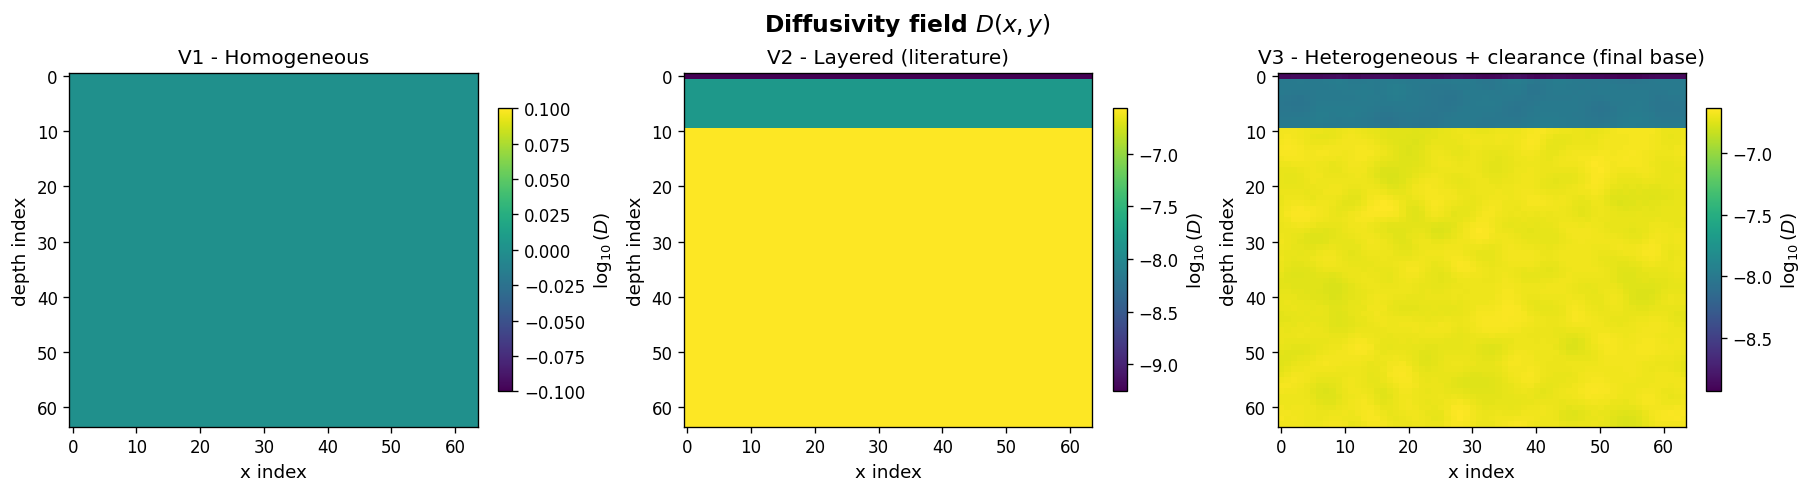

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
fig.suptitle('Diffusivity field $D(x, y)$', fontsize=14, fontweight='bold')

for ax, (label, r) in zip(axes, runs.items()):
    im = ax.imshow(np.log10(r['D_field'] + 1e-30), origin='upper', aspect='auto', cmap='viridis')
    ax.set_title(label)
    ax.set_xlabel('x index')
    ax.set_ylabel('depth index')
    fig.colorbar(im, ax=ax, shrink=0.8, label='$\\log_{10}(D)$')

plt.show()

## 3 - Concentration field comparisons

### 3.1 - Final-time snapshots (absolute concentration)

This first view compares each regime at its final saved time.  
It is useful for endpoint interpretation (retention after each regime horizon), but note the horizons differ: V1 ends at 1 s, while V2/V3 end at 86,400 s.


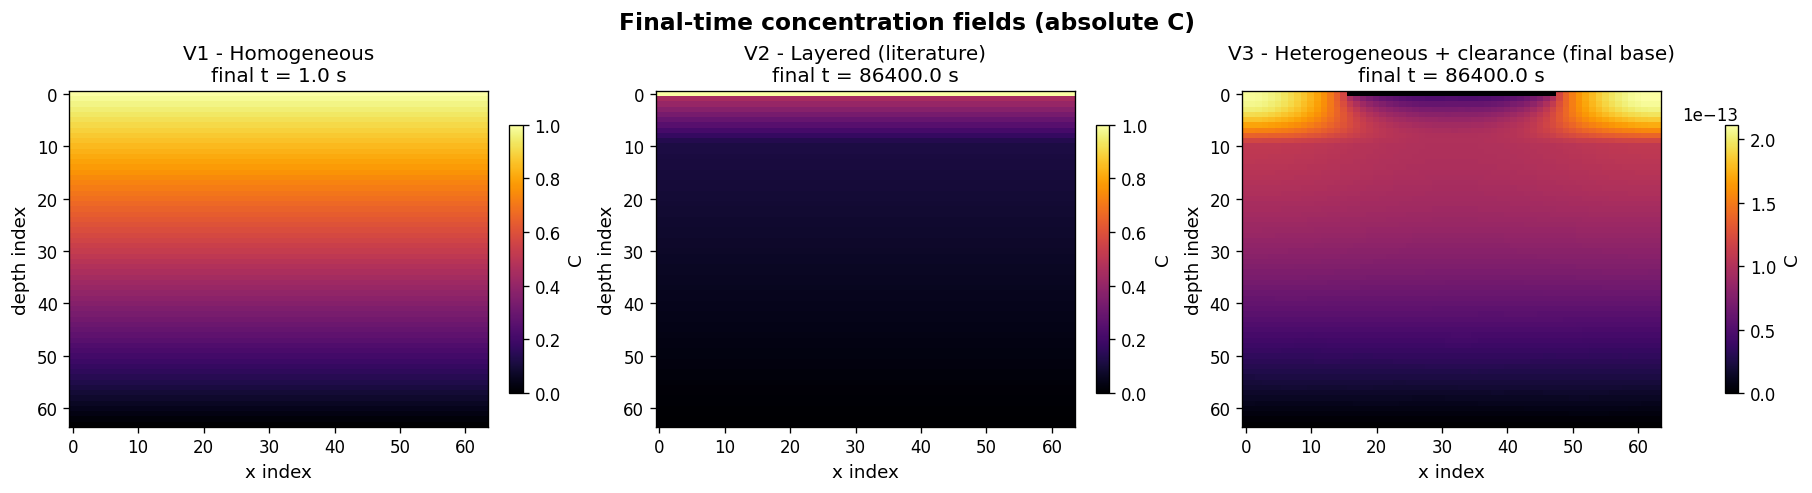

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
fig.suptitle('Final-time concentration fields (absolute C)', fontsize=14, fontweight='bold')

for ax, (label, r) in zip(axes, runs.items()):
    frame = r['C_snap'][-1]
    im = ax.imshow(frame, origin='upper', aspect='auto', cmap='inferno')
    ax.set_title(f"{label}\nfinal t = {r['t_save'][-1]:.1f} s")
    ax.set_xlabel('x index')
    ax.set_ylabel('depth index')
    fig.colorbar(im, ax=ax, shrink=0.8, label='C')

plt.show()

**Breakdown.**

- Final-time panels are best for endpoint comparisons (how much concentration remains at each regime horizon).
- V1 and V2 now use full-width donor exposure, while V3 uses a half-width finite-dose donor; this is why V3 keeps stronger lateral structure.
- V2 remains top-layer dominated at 24 h because low SC diffusivity limits deep penetration.
- For like-for-like event comparison across regimes, use the peak-time figure in Section 3.2.


### 3.2 - Peak-flux snapshots ($t_{peak}$): absolute magnitude vs normalized shape

This view aligns all regimes at the same event type: the time of peak bottom flux ($t_{peak}$).  
Top row compares absolute concentration magnitudes (global log scale across regimes).  
Bottom row removes magnitude and compares spatial pattern only ($C / C_{peak,max}$).


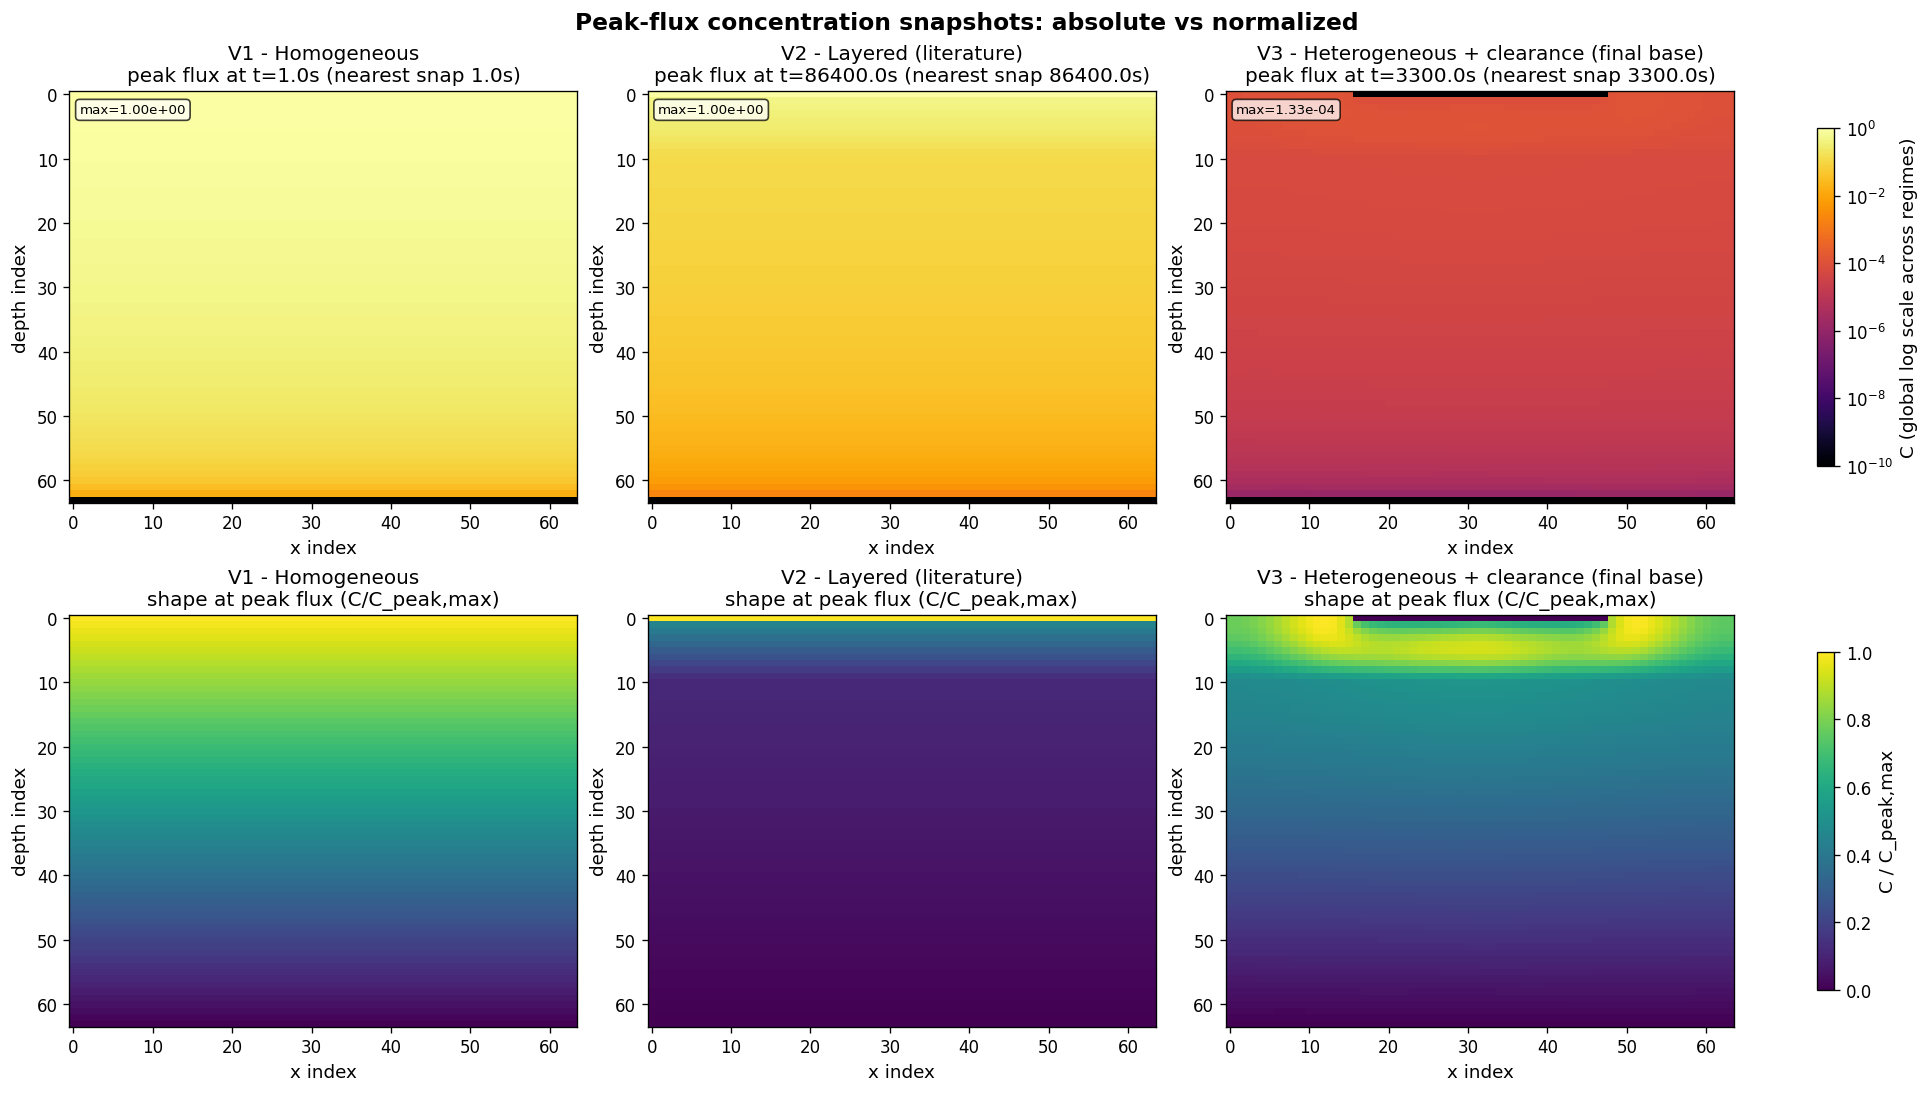

In [5]:
from matplotlib.colors import LogNorm

regime_items = list(runs.items())

peak_frames = []
peak_flux_times = []
peak_snap_times = []
peak_labels = []

for label, r in regime_items:
    t_save = np.array(r['t_save'], dtype=float)
    C = r['C_snap']
    t_flux = np.array(r['metrics']['t'], dtype=float)
    J = np.array(r['metrics']['J'], dtype=float)

    peak_flux_idx = int(np.argmax(J))
    t_peak_flux = float(t_flux[peak_flux_idx])
    snap_peak_idx = int(np.argmin(np.abs(t_save - t_peak_flux)))

    peak_frame = C[snap_peak_idx]

    peak_labels.append(label)
    peak_frames.append(peak_frame)
    peak_flux_times.append(t_peak_flux)
    peak_snap_times.append(float(t_save[snap_peak_idx]))

# Global absolute scale across regimes for a fair magnitude comparison
abs_global_max = max(max(float(np.max(f)), 1e-30) for f in peak_frames)
abs_floor = max(abs_global_max * 1e-10, 1e-30)
abs_norm = LogNorm(vmin=abs_floor, vmax=abs_global_max)

fig, axes = plt.subplots(2, len(peak_frames), figsize=(16, 9), constrained_layout=True)
fig.suptitle('Peak-flux concentration snapshots: absolute vs normalized', fontsize=14, fontweight='bold')

for col, (label, frame, t_peak_flux, t_peak_snap) in enumerate(
    zip(peak_labels, peak_frames, peak_flux_times, peak_snap_times)
):
    # Top row: absolute concentration
    ax_abs = axes[0, col]
    im_abs = ax_abs.imshow(np.clip(frame, abs_floor, None), origin='upper', aspect='auto',
                           cmap='inferno', norm=abs_norm)
    ax_abs.set_title(f'{label}\npeak flux at t={t_peak_flux:.1f}s (nearest snap {t_peak_snap:.1f}s)')
    ax_abs.set_xlabel('x index')
    ax_abs.set_ylabel('depth index')
    ax_abs.text(0.02, 0.97, f'max={float(np.max(frame)):.2e}', transform=ax_abs.transAxes,
                ha='left', va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.75))

    # Bottom row: normalized by that regime's own peak max
    ax_norm = axes[1, col]
    frame_peak_max = max(float(np.max(frame)), 1e-30)
    frame_norm = frame / frame_peak_max
    im_norm = ax_norm.imshow(frame_norm, origin='upper', aspect='auto',
                             cmap='viridis', vmin=0.0, vmax=1.0)
    ax_norm.set_title(f'{label}\nshape at peak flux (C/C_peak,max)')
    ax_norm.set_xlabel('x index')
    ax_norm.set_ylabel('depth index')

fig.colorbar(im_abs, ax=axes[0, :], shrink=0.82, label='C (global log scale across regimes)')
fig.colorbar(im_norm, ax=axes[1, :], shrink=0.82, label='C / C_peak,max')

plt.show()


**Breakdown.**

- Top row answers: which regime has larger absolute concentration when transport is most active (its own $t_{peak}$).
- Bottom row answers: how concentration is spatially distributed once each regime is rescaled to its own peak level.
- Using both rows avoids misleading interpretation from either scale-only or shape-only views.


### 3.3 - Regime evolution GIFs at matched normalized time ($\tau=t/T$)

These GIFs compare time evolution at matched normalized times so fast and slow regimes can be viewed on the same progression scale.



- `v123_regime_evolution_tau_abs.gif` uses **absolute concentration** (log scale). Use this for statements about dose level, depletion, and retention.
- `v123_regime_evolution_tau_shape.gif` uses **frame-normalized concentration** (`C / frame max`). Use this for statements about spatial pattern only.
- Both GIFs use the same normalized-time frames; only colour scaling differs.


Saved GIF (absolute): /run/media/sc23n2w/DATA/COMP3931_IndividualProject/figures/validation/v123_regime_evolution_tau_abs.gif
Saved GIF (shape):    /run/media/sc23n2w/DATA/COMP3931_IndividualProject/figures/validation/v123_regime_evolution_tau_shape.gif


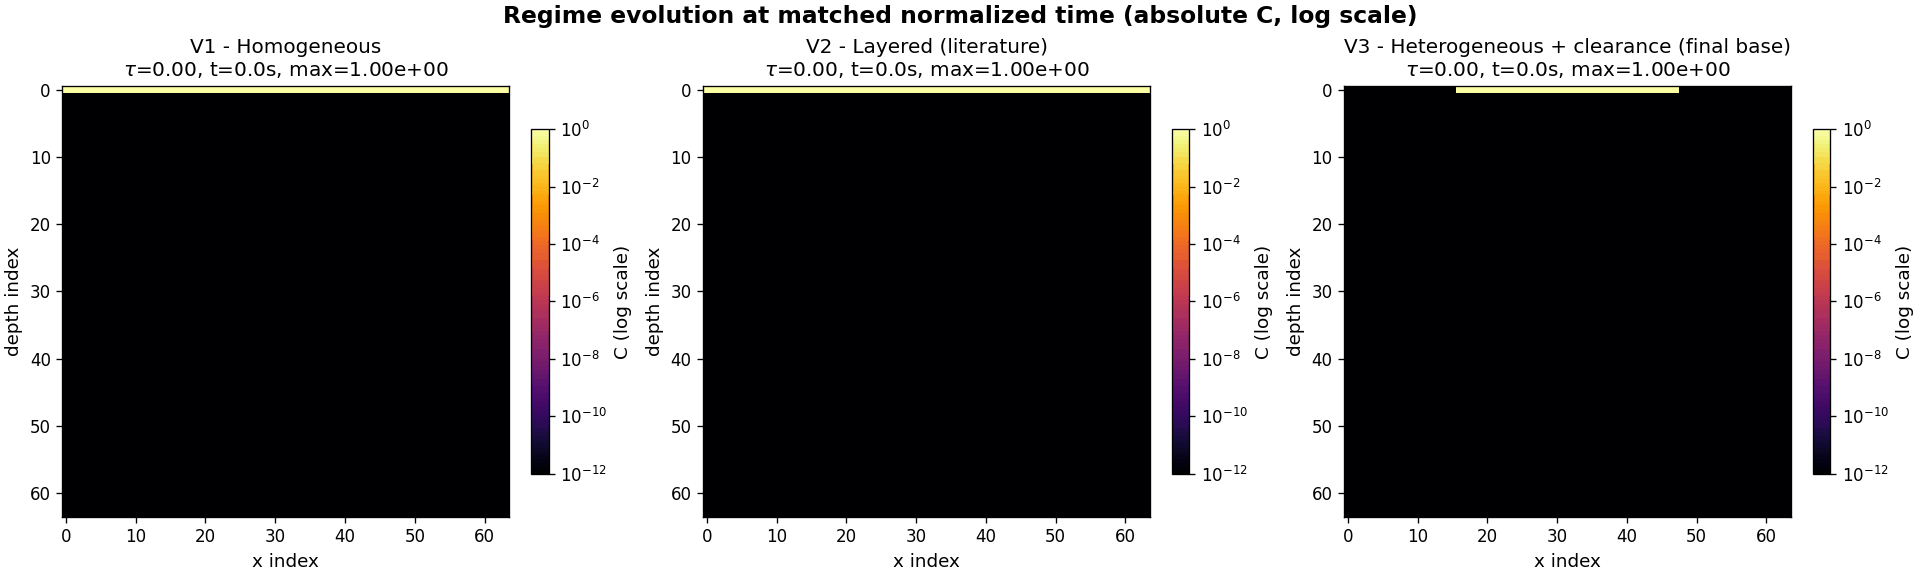

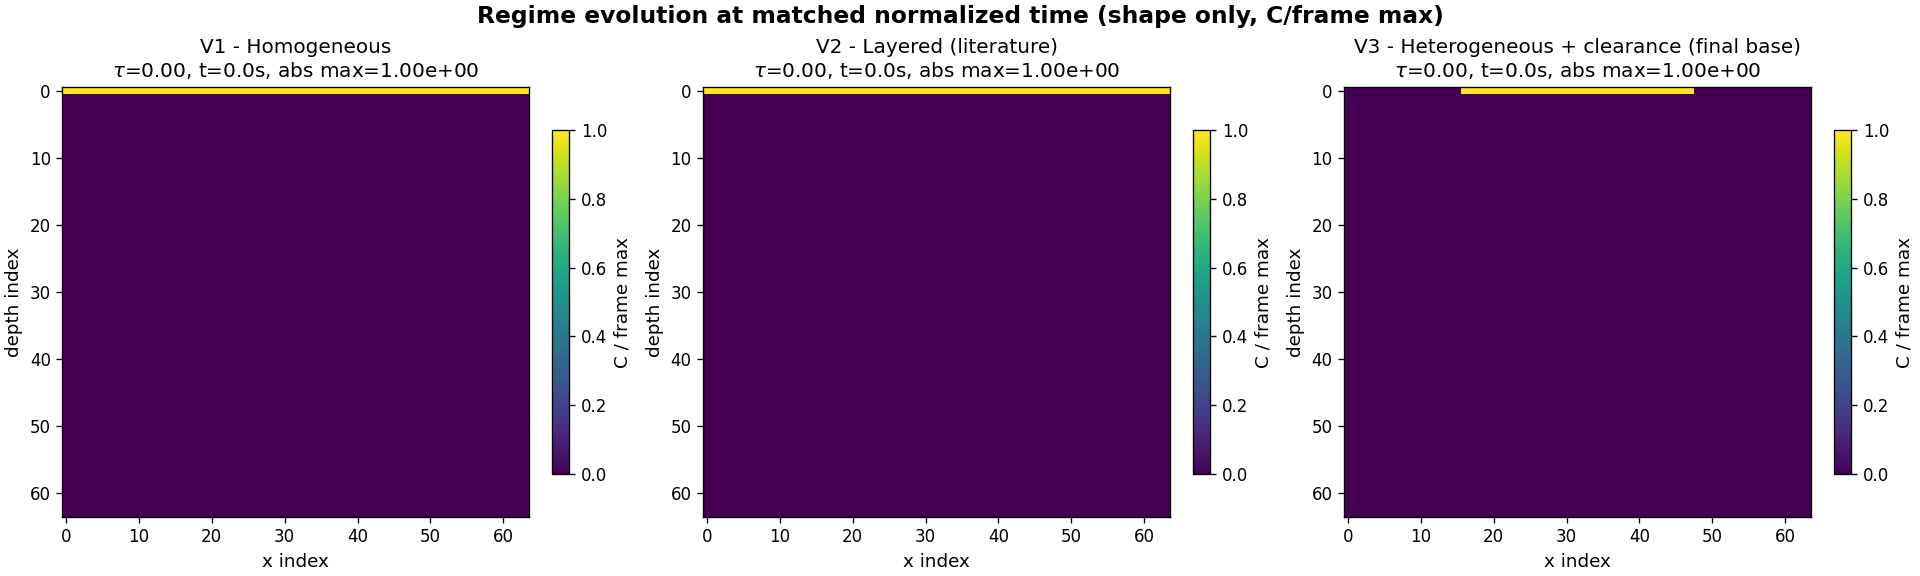

In [ ]:
from matplotlib.colors import LogNorm
from matplotlib.animation import FuncAnimation, PillowWriter
from pathlib import Path
from IPython.display import Image, display

regime_items = list(runs.items())
out_dir = Path('figures/validation')
out_dir.mkdir(parents=True, exist_ok=True)

# Early-time emphasis so fast-decay V3 remains informative for more frames.
n_frames = 48
u = np.linspace(0.0, 1.0, n_frames)
tau_anim = u**2  # denser near tau=0

# D1) Absolute concentration GIF (log scale, per-regime fixed norm)
fig, axes = plt.subplots(1, len(regime_items), figsize=(16, 4.8), constrained_layout=True)
fig.suptitle('Regime evolution at matched normalized time (absolute C, log scale)', fontsize=14, fontweight='bold')

images_abs = []
meta_abs = []
for ax, (label, r) in zip(axes, regime_items):
    t = np.array(r['t_save'], dtype=float)
    C = r['C_snap']
    cmax = max(float(np.max(C)), 1e-30)
    floor = max(cmax * 1e-12, 1e-30)
    norm = LogNorm(vmin=floor, vmax=cmax)

    img = ax.imshow(np.clip(C[0], floor, None), origin='upper', aspect='auto',
                    cmap='inferno', norm=norm)
    ax.set_title(f'{label}\n$\\tau$=0.00, t={t[0]:.1f}s, max={np.max(C[0]):.2e}')
    ax.set_xlabel('x index')
    ax.set_ylabel('depth index')
    fig.colorbar(img, ax=ax, shrink=0.8, label='C (log scale)')

    images_abs.append(img)
    meta_abs.append((label, t, C, floor))


def update_abs(k):
    tau = float(tau_anim[k])
    artists = []
    for ax, img, (label, t, C, floor) in zip(axes, images_abs, meta_abs):
        target_t = tau * t[-1]
        idx = int(np.argmin(np.abs(t - target_t)))
        frame = C[idx]
        img.set_data(np.clip(frame, floor, None))
        ax.set_title(f'{label}\n$\\tau$={tau:.2f}, t={t[idx]:.1f}s, max={np.max(frame):.2e}')
        artists.append(img)
    return artists

ani_abs = FuncAnimation(fig, update_abs, frames=n_frames, interval=140, blit=False)
gif_abs = out_dir / 'v123_regime_evolution_tau_abs.gif'
ani_abs.save(gif_abs, writer=PillowWriter(fps=7))
plt.close(fig)

# D2) Shape-only GIF (frame normalized to own max)
fig, axes = plt.subplots(1, len(regime_items), figsize=(16, 4.8), constrained_layout=True)
fig.suptitle('Regime evolution at matched normalized time (shape only, C/frame max)', fontsize=14, fontweight='bold')

images_shape = []
meta_shape = []
for ax, (label, r) in zip(axes, regime_items):
    t = np.array(r['t_save'], dtype=float)
    C = r['C_snap']
    fmax0 = max(float(np.max(C[0])), 1e-30)

    img = ax.imshow(C[0] / fmax0, origin='upper', aspect='auto',
                    cmap='viridis', vmin=0.0, vmax=1.0)
    ax.set_title(f'{label}\n$\\tau$=0.00, t={t[0]:.1f}s, abs max={fmax0:.2e}')
    ax.set_xlabel('x index')
    ax.set_ylabel('depth index')
    fig.colorbar(img, ax=ax, shrink=0.8, label='C / frame max')

    images_shape.append(img)
    meta_shape.append((label, t, C))


def update_shape(k):
    tau = float(tau_anim[k])
    artists = []
    for ax, img, (label, t, C) in zip(axes, images_shape, meta_shape):
        target_t = tau * t[-1]
        idx = int(np.argmin(np.abs(t - target_t)))
        frame = C[idx]
        fmax = max(float(np.max(frame)), 1e-30)
        img.set_data(frame / fmax)
        ax.set_title(f'{label}\n$\\tau$={tau:.2f}, t={t[idx]:.1f}s, abs max={fmax:.2e}')
        artists.append(img)
    return artists

ani_shape = FuncAnimation(fig, update_shape, frames=n_frames, interval=140, blit=False)
gif_shape = out_dir / 'v123_regime_evolution_tau_shape.gif'
ani_shape.save(gif_shape, writer=PillowWriter(fps=7))
plt.close(fig)

print(f'Saved GIF (absolute): {gif_abs.resolve()}')
print(f'Saved GIF (shape):    {gif_shape.resolve()}')

# Show previews in notebook
for p in [gif_abs, gif_shape]:
    display(Image(filename=str(p)))

## 4 - Flux curves compared

The shape of $J(t)$ changes dramatically across regimes:
- **V1** shows classic diffusion rise to steady state
- **V2** exhibits a delayed onset due to the high-resistance SC layer
- **V3** peaks and decays because of the finite (time-decaying) donor

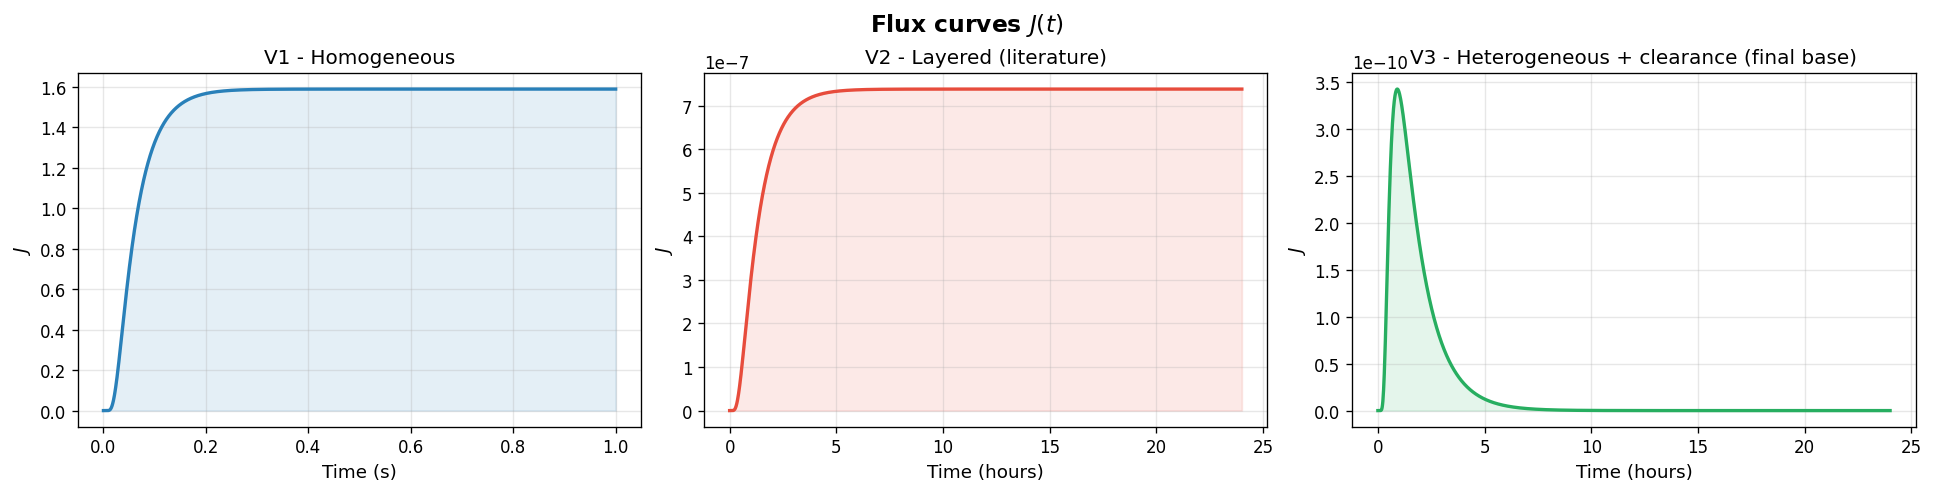

In [7]:
colours = ['#2980b9', '#e74c3c', '#27ae60']

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
fig.suptitle('Flux curves $J(t)$', fontsize=14, fontweight='bold')

for ax, (label, r), c in zip(axes, runs.items(), colours):
    J = np.array(r['metrics']['J'], dtype=float)
    t = np.array(r['metrics']['t'], dtype=float)
    # Normalise time to hours for V2/V3 (long runs), seconds for V1
    if r['cfg'].grid.T > 100:
        t_plot = t / 3600.0
        xlabel = 'Time (hours)'
    else:
        t_plot = t
        xlabel = 'Time (s)'
    ax.plot(t_plot, J, lw=2, color=c)
    ax.fill_between(t_plot, 0, J, alpha=0.12, color=c)
    ax.set_title(label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('$J$')
    ax.grid(alpha=0.3)

plt.show()

**Breakdown.**

- **V1** — Flux rises monotonically toward steady state within its short horizon (classic constant-source diffusion profile).
- **V2** — Shows delayed onset and low steady-state flux due to strong SC barrier resistance under infinite-dose driving.
- **V3** — Peaks and then decays because the time-decaying donor depletes source concentration; this finite-dose behaviour is the basis for the final surrogate dataset setting.

Use the printed metrics from this run (above) for exact numeric values rather than hard-coded constants in markdown.